# IMU Data Sanity Check & Analysis

Analyze accelerometer data from smartwatches to validate signal quality and detect motion patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## Load IMU CSV Files

In [2]:
# Load IMU data files (skip comment lines starting with #)
data_dir = Path('../data')
imu_files = sorted(data_dir.glob('*.csv'))

print(f"Found {len(imu_files)} IMU files:")
for f in imu_files:
    print(f"  - {f.name}")

# Load first file as example
if imu_files:
    imu_data = pd.read_csv(imu_files[0], comment='#')
    print(f"\nShape: {imu_data.shape}")
    print(f"Columns: {list(imu_data.columns)}")
    print(f"\nFirst few rows:")
    print(imu_data.head())

Found 1 IMU files:
  - climb_20260625_105842_81af6997.csv

Shape: (831, 11)
Columns: ['Time(ms)', 'Sensor', 'Accel.X(m/s²)', 'Accel.Y(m/s²)', 'Accel.Z(m/s²)', 'Gyro.X(rad/s)', 'Gyro.Y(rad/s)', 'Gyro.Z(rad/s)', 'Heart(bpm)', 'Pressure(hPa)', 'Altitude(m)']

First few rows:
   Time(ms) Sensor  Accel.X(m/s²)  Accel.Y(m/s²)  Accel.Z(m/s²)  \
0       102  fused       0.000000       0.000000       0.000000   
1       124  fused      -0.331404       0.300564       9.852358   
2       144  fused      -0.398478       0.870693       9.663114   
3       167  fused      -0.372128       1.347397       9.730187   
4       200  fused      -0.472739       0.501786       9.766120   

   Gyro.X(rad/s)  Gyro.Y(rad/s)  Gyro.Z(rad/s)  Heart(bpm)  Pressure(hPa)  \
0            0.0            0.0            0.0         0.0            0.0   
1            0.0            0.0            0.0         0.0            0.0   
2            0.0            0.0            0.0         0.0            0.0   
3            0.0

## Compute Accelerometer Statistics

In [3]:
def analyze_imu(df, name="IMU"):
    """Compute sanity check stats for IMU data."""
    
    # Extract accelerometer components
    accel_x = pd.to_numeric(df['Accel.X(m/s²)'], errors='coerce').dropna()
    accel_y = pd.to_numeric(df['Accel.Y(m/s²)'], errors='coerce').dropna()
    accel_z = pd.to_numeric(df['Accel.Z(m/s²)'], errors='coerce').dropna()
    
    # Magnitude
    accel_mag = np.sqrt(accel_x**2 + accel_y**2 + accel_z**2)
    
    # Statistics
    stats = {
        'name': name,
        'samples': len(accel_mag),
        'mean': accel_mag.mean(),
        'std': accel_mag.std(),
        'min': accel_mag.min(),
        'max': accel_mag.max(),
        'peak_range': accel_mag.max() - accel_mag.min(),
        'gravity_error': abs(accel_mag.mean() - 9.81),
    }
    
    # Peak detection (spikes > mean + 2*std)
    threshold = stats['mean'] + 2 * stats['std']
    stats['peak_spikes'] = (accel_mag > threshold).sum()
    
    # Motion classification
    if stats['std'] > 1.0:
        stats['motion_level'] = 'HIGH (strong motion)'
    elif stats['std'] > 0.3:
        stats['motion_level'] = 'MODERATE (some motion)'
    else:
        stats['motion_level'] = 'LOW (at rest)'
    
    # Sanity checks
    stats['gravity_ok'] = stats['gravity_error'] < 1.5
    stats['motion_detected'] = stats['std'] > 0.5
    stats['signal_quality'] = 'GOOD' if (stats['gravity_ok'] and stats['peak_spikes'] > 5) else 'CHECK'
    
    return stats, accel_mag

# Analyze loaded IMU
stats, accel_mag = analyze_imu(imu_data, name=imu_files[0].stem)

# Print report
print(f"\n{'='*60}")
print(f"IMU DATA ANALYSIS: {stats['name']}")
print(f"{'='*60}")
print(f"Samples:           {stats['samples']}")
print(f"\nACCELEROMETER (magnitude):")
print(f"  Mean:            {stats['mean']:.2f} m/s² (gravity ≈ 9.81)")
print(f"  Std Dev:         {stats['std']:.2f} m/s² (noise/motion indicator)")
print(f"  Min/Max:         {stats['min']:.2f} / {stats['max']:.2f} m/s²")
print(f"  Peak Range:      {stats['peak_range']:.2f} m/s²")
print(f"\nSANITY CHECKS:")
print(f"  Motion Level:    {stats['motion_level']}")
print(f"  Gravity Error:   {stats['gravity_error']:.2f} m/s² {'✓ OK' if stats['gravity_ok'] else '⚠ OFF'}")
print(f"  Peak Spikes:     {stats['peak_spikes']} (movement signatures)")
print(f"  Signal Quality:  {stats['signal_quality']}")
print(f"\nEXPECTED FOR SIDE-TO-SIDE MOTION:")
print(f"  ✓ Std Dev > 0.5 m/s² (oscillation)")
print(f"  ✓ Peak Range > 2.0 m/s² (amplitude)")
print(f"  ✓ Peak Spikes > 10 (quick jerky moves)")
print(f"\n{'='*60}")


IMU DATA ANALYSIS: climb_20260625_105842_81af6997
Samples:           831

ACCELEROMETER (magnitude):
  Mean:            10.29 m/s² (gravity ≈ 9.81)
  Std Dev:         2.72 m/s² (noise/motion indicator)
  Min/Max:         0.00 / 50.04 m/s²
  Peak Range:      50.04 m/s²

SANITY CHECKS:
  Motion Level:    HIGH (strong motion)
  Gravity Error:   0.48 m/s² ✓ OK
  Peak Spikes:     12 (movement signatures)
  Signal Quality:  GOOD

EXPECTED FOR SIDE-TO-SIDE MOTION:
  ✓ Std Dev > 0.5 m/s² (oscillation)
  ✓ Peak Range > 2.0 m/s² (amplitude)
  ✓ Peak Spikes > 10 (quick jerky moves)



## Plot Accelerometer Signal

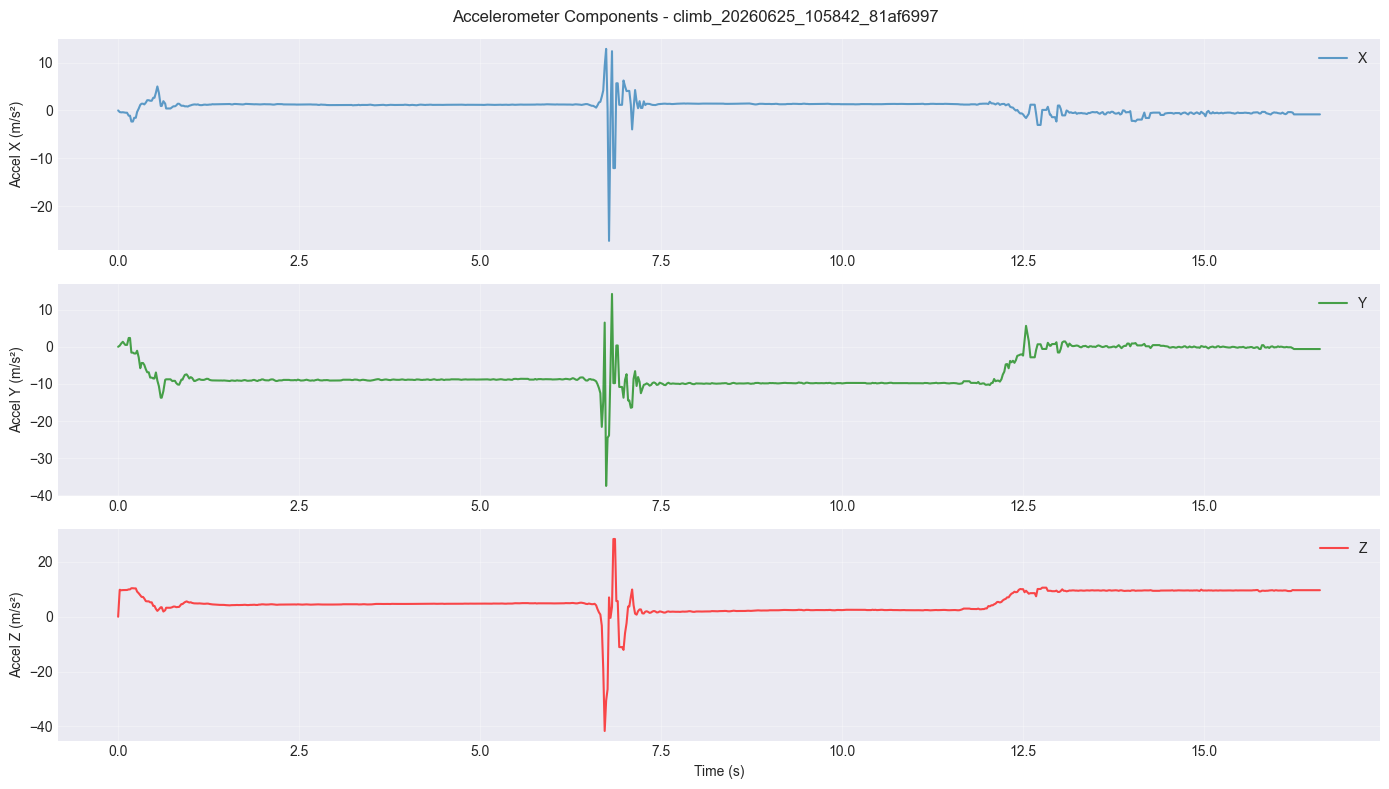

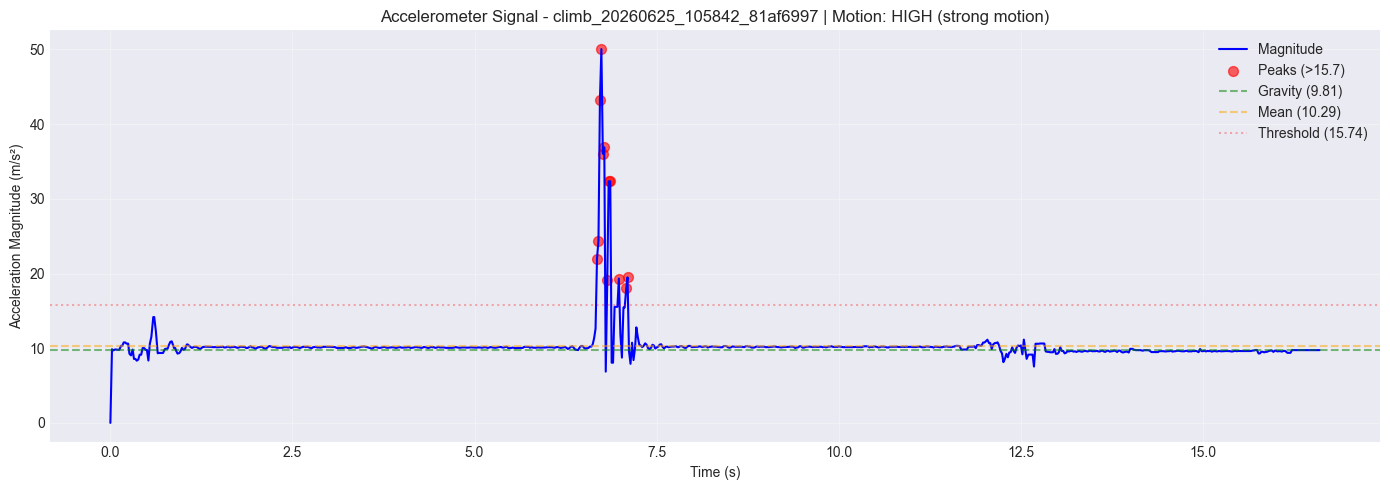

In [4]:
# Extract time for plotting
time_ms = pd.to_numeric(imu_data['Time(ms)'], errors='coerce')
time_s = (time_ms - time_ms.iloc[0]) / 1000

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

accel_x = pd.to_numeric(imu_data['Accel.X(m/s²)'], errors='coerce')
accel_y = pd.to_numeric(imu_data['Accel.Y(m/s²)'], errors='coerce')
accel_z = pd.to_numeric(imu_data['Accel.Z(m/s²)'], errors='coerce')

# Individual components
axes[0].plot(time_s, accel_x, label='X', alpha=0.7)
axes[0].set_ylabel('Accel X (m/s²)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(time_s, accel_y, label='Y', color='green', alpha=0.7)
axes[1].set_ylabel('Accel Y (m/s²)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(time_s, accel_z, label='Z', color='red', alpha=0.7)
axes[2].set_ylabel('Accel Z (m/s²)')
axes[2].set_xlabel('Time (s)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.suptitle(f'Accelerometer Components - {stats["name"]}')
plt.tight_layout()
plt.show()

# Magnitude plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_s, accel_mag, label='Magnitude', linewidth=1.5, color='blue')

# Highlight peaks
threshold = stats['mean'] + 2 * stats['std']
peaks = accel_mag > threshold
ax.scatter(time_s[peaks], accel_mag[peaks], color='red', s=50, alpha=0.6, label=f'Peaks (>{threshold:.1f})')

# Reference lines
ax.axhline(y=9.81, color='green', linestyle='--', alpha=0.5, label='Gravity (9.81)')
ax.axhline(y=stats['mean'], color='orange', linestyle='--', alpha=0.5, label=f'Mean ({stats["mean"]:.2f})')
ax.axhline(y=threshold, color='red', linestyle=':', alpha=0.3, label=f'Threshold ({threshold:.2f})')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration Magnitude (m/s²)')
ax.set_title(f'Accelerometer Signal - {stats["name"]} | Motion: {stats["motion_level"]}')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Analyze All IMU Files (Batch)

In [5]:
# Load and analyze all IMU files
all_stats = []

for imu_file in imu_files:
    try:
        df = pd.read_csv(imu_file, comment='#')
        stats, _ = analyze_imu(df, name=imu_file.stem)
        all_stats.append(stats)
        print(f"✓ {imu_file.name}")
    except Exception as e:
        print(f"✗ {imu_file.name}: {e}")

# Create comparison dataframe
comparison_df = pd.DataFrame(all_stats)
print(f"\n{comparison_df.to_string()}")

✓ climb_20260625_105842_81af6997.csv

                             name  samples       mean       std  min        max  peak_range  gravity_error  peak_spikes          motion_level  gravity_ok  motion_detected signal_quality
0  climb_20260625_105842_81af6997      831  10.294091  2.723681  0.0  50.041407   50.041407       0.484091           12  HIGH (strong motion)        True             True           GOOD


## Side-by-Side Comparison

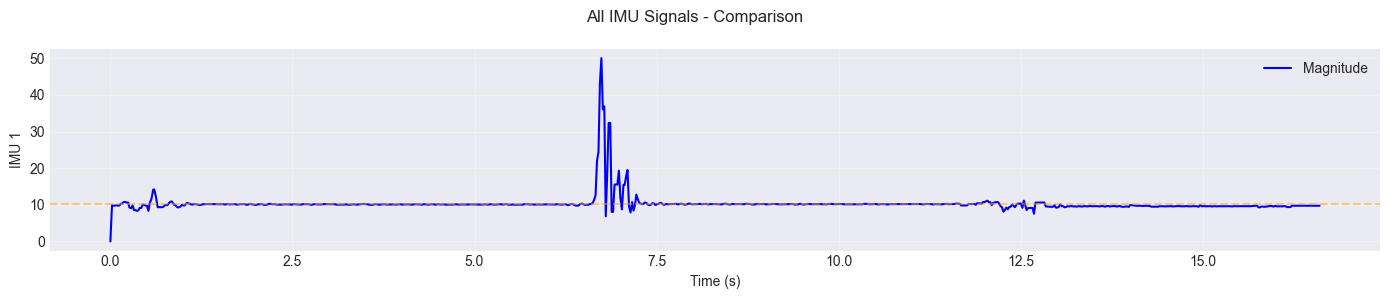

In [6]:
# Plot all IMU signals for comparison
fig, axes = plt.subplots(len(all_stats), 1, figsize=(14, 3*len(all_stats)))

if len(all_stats) == 1:
    axes = [axes]

colors = ['blue', 'green', 'red', 'purple', 'orange']

for idx, (imu_file, ax, color) in enumerate(zip(imu_files, axes, colors)):
    df = pd.read_csv(imu_file, comment='#')
    time_ms = pd.to_numeric(df['Time(ms)'], errors='coerce')
    time_s = (time_ms - time_ms.iloc[0]) / 1000
    
    accel_x = pd.to_numeric(df['Accel.X(m/s²)'], errors='coerce')
    accel_y = pd.to_numeric(df['Accel.Y(m/s²)'], errors='coerce')
    accel_z = pd.to_numeric(df['Accel.Z(m/s²)'], errors='coerce')
    accel_mag = np.sqrt(accel_x**2 + accel_y**2 + accel_z**2)
    
    stats = all_stats[idx]
    ax.plot(time_s, accel_mag, label='Magnitude', color=color, linewidth=1.5)
    ax.axhline(y=stats['mean'], color='orange', linestyle='--', alpha=0.5)
    ax.set_ylabel(f"IMU {idx+1}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time (s)')
plt.suptitle('All IMU Signals - Comparison')
plt.tight_layout()
plt.show()

## Summary Table

In [7]:
# Create clean summary
summary = comparison_df[[
    'name', 'samples', 'mean', 'std', 'peak_range', 
    'gravity_error', 'peak_spikes', 'motion_level', 'signal_quality'
]].copy()

summary.columns = ['Device', 'Samples', 'Mean (m/s²)', 'Std (m/s²)', 'Peak Range', 
                   'Gravity Err', 'Spikes', 'Motion', 'Quality']

print("\n" + "="*100)
print("IMU DATA SANITY CHECK SUMMARY")
print("="*100)
print(summary.to_string(index=False))
print("\nINTERPRETATION:")
print("  • Mean ≈ 9.81:  Good (at rest) | > 10 or < 9: Sensor tilted/moving")
print("  • Std > 0.5:    Motion detected ✓ | < 0.3: No motion")
print("  • Peak Range:   Amplitude of motion (>2.0 = significant)")
print("  • Spikes:       Count of rapid accelerations (>10 = jerky motion)")
print("  • Gravity Err:  <1.5 is OK, >2 might indicate tilted sensor")
print("="*100)


IMU DATA SANITY CHECK SUMMARY
                        Device  Samples  Mean (m/s²)  Std (m/s²)  Peak Range  Gravity Err  Spikes               Motion Quality
climb_20260625_105842_81af6997      831    10.294091    2.723681   50.041407     0.484091      12 HIGH (strong motion)    GOOD

INTERPRETATION:
  • Mean ≈ 9.81:  Good (at rest) | > 10 or < 9: Sensor tilted/moving
  • Std > 0.5:    Motion detected ✓ | < 0.3: No motion
  • Peak Range:   Amplitude of motion (>2.0 = significant)
  • Spikes:       Count of rapid accelerations (>10 = jerky motion)
  • Gravity Err:  <1.5 is OK, >2 might indicate tilted sensor
